### Introduction

This jupyter file contains all the answers to the questions posed in the practical document.

Verifications:

1. <iframe width="100%" height="800" src="test.pdf">

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from matplotlib.ticker import MultipleLocator

## a) Implementation of the Verlet algorithm

$F[x,\dot{x},t]= 2ax - 4bx^3 +F_0\cos(\omega t)$

In [44]:
def F(x,t):
    return 2*a*x-4*b*x**3+F0*np.cos(w*t)

$v_{half} \rightarrow \qquad v(t+\frac{h}{2}) = (1-\gamma \frac{h}{2})v(t) + \frac{h}{2} F(x(t),t)\\$
$x_{new} \rightarrow \qquad x(t+h) = x(t) + hv(t+\frac{h}{2})\\$
$v_{new} \rightarrow \qquad \frac{v(t+\frac{h}{2})+\frac{h}{2}F(x(t+h), t+h)}{1+\gamma \frac{h}{2}}$

In [45]:
def Verlet(x,v,t,h):
    v_half = (1-gamma*h/2)*v+h/2*F(x,t)
    x_new = x + h * v_half
    F_new = F(x_new,t+h)
    v_new =(v_half+h/2*F_new)/(1+h/2*gamma)
    return x_new,v_new

### Verlet Error Analysis

To show numerically that for a conservative Hamiltonian this algorithm preserves the energy we remove the $\gamma$ and $F_0$ terms be setting them equal to zero.

In [51]:
# Defining various constants
gamma = 0
a = 0.5
b = 0.25

F0 = 0
w= 2.4

# Creating the necessary time array
N = 100000
t = np.linspace(0,50,N)
h = t[1]-t[0]

# Initial conditions
x0 = 0.5
v0 = 0


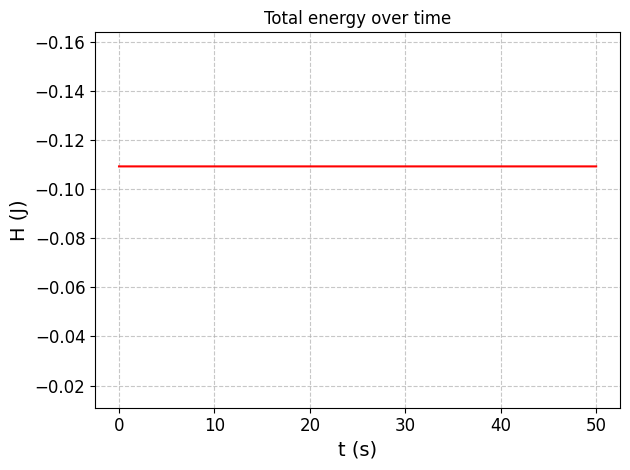

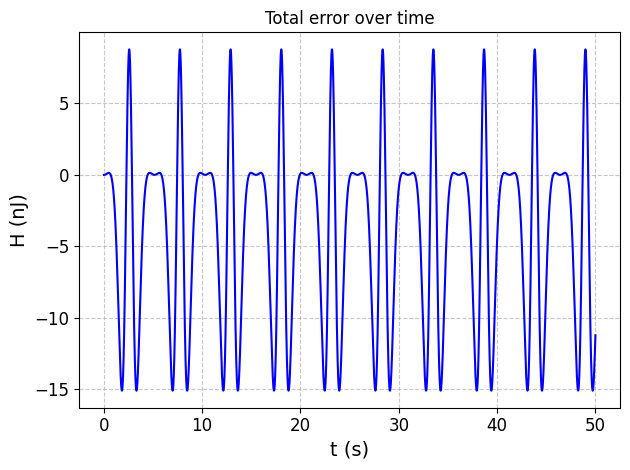

6.332586045892137e-09


In [52]:
# Setting up the iteration results array
x = np.zeros(N)
v = np.zeros(N)
x[0],v[0] = x0,v0

# Using Verlet algorithm
for i in range(1,N):
    x[i],v[i] = Verlet(x[i-1],v[i-1],t[i-1],h)


# Calculating The total energy
T = 0.5*v**2        # Kinetic energy (J)
V = -a*x**2+b*x**4  # Potential energy (J) from integrating -F(x,t)
H = T+V             # Hamiltonian

# Examining numerical error over time: If H is conserved it should remain te same as in the beginning
H0 = H[0]
error = H-H0


# Plotting H
plt.ylabel("H (J)", fontsize=14)
plt.xlabel("t (s)", fontsize=14)
plt.plot(t,H, 'r-')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Total energy over time")
plt.ylim(H0*0.1,H0*1.5)
plt.tight_layout()
plt.show()

# Plotting code
# a = np.arange(0,50,2*np.pi/w)
plt.ylabel("H (nJ)", fontsize=14)
plt.xlabel("t (s)", fontsize=14)
plt.plot(t,error*1e9, 'b-')
# plt.plot(t,(V-V[0])*80)
# plt.plot(t,(K-K[0])*80)
# plt.plot(a,np.zeros(len(a)),"c.",ms = 10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Total error over time")
plt.savefig("Total error over time.png")
plt.tight_layout()
plt.show()

print(np.std(error))


We see that the Hamiltonian stays constant, but the error seems to be oscillating over time. By finding the peaks we can examine if the error changes over time.

[ 5156 15468 25781 36093 46405 56717 67029 77342 87654 97966]
The computational error at t=50 is -1.1e-08 J. The error oscillation increased with approximately 2.1e-14 J over time.


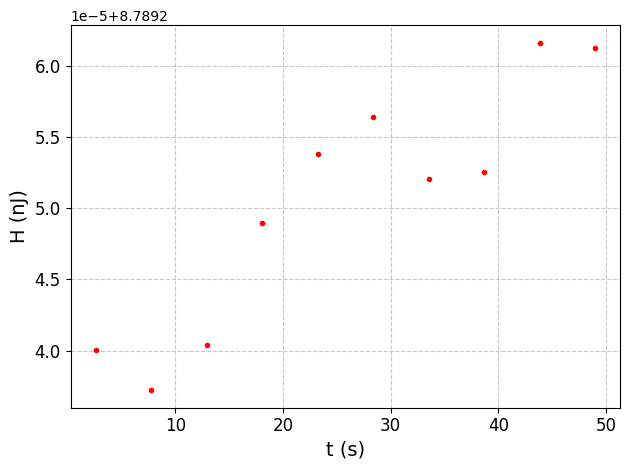

8.789261221608946e-09


In [55]:
# Using find peaks to find the top peaks of the oscillation.
peak_indices, _ = find_peaks(error, height=1e-9)
print(peak_indices)
error_p = error[peak_indices]
t_p = t[peak_indices]

#Printing the difference
error_diff = error_p[-1]-error_p[0]
print('The computational error at t=%.f is %.1e J. The error oscillation increased with approximately %.1e J over time.'%(t[-1], error[-1], error_diff))

#Plotting error peaks
plt.ylabel("H (nJ)", fontsize=14)
plt.xlabel("t (s)", fontsize=14)
plt.plot(t_p,error_p*1e9, 'r.')
# plt.plot(t,error*1e9)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
# plt.ylim(8.7,8.8)
plt.savefig("Error over time.png")
plt.show()

print(error_p[-1])


We can see that the error increases over time, but only a neglible amount.

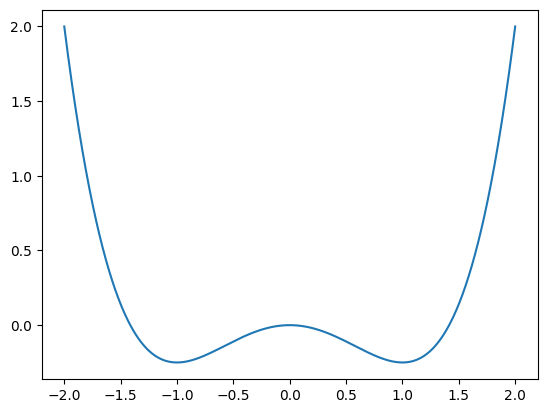

In [92]:
x = np.linspace(-2,2,1000)
V = -a*x**2+b*x**4
plt.plot(x,V)

(None, None)

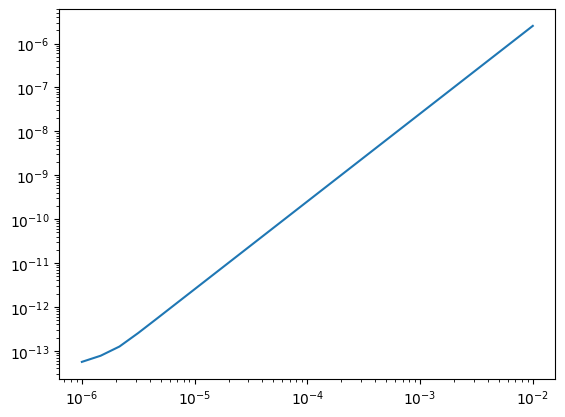

In [41]:
n_par = 25
h = np.geomspace(1e-2,1e-6,n_par)
error_std = np.zeros(n_par)

for i in range(n_par):
    t = np.arange(0,30,h[i])
    N = len(t)
    x = np.zeros(N)
    v = np.zeros(N)
    x[0], v[0] = 0.5,0
    for j in range(1, N):  #Solve for x and v using Verlet algorithm
        x[j], v[j] = Verlet(x[j - 1], v[j - 1], t[j - 1],h[i])
    # Calculating The total energy
    T = 0.5*v**2        # Kinetic energy (J)
    V = -a*x**2+b*x**4  # Potential energy (J) from integrating -F(x,t)
    H = T+V             # Hamiltonian

    # Examining numerical error over time: If H is conserved it should remain te same as in the beginning
    H0 = H[0]
    error = H-H0
    error_std[i] = np.std(error)

plt.plot(h,error_std)
plt.yscale("log"),plt.xscale("log")



## b) Duffing Oscillator using Verlet Algorithm

In [87]:
# Defining various constants
gamma = 0.1
a = 0.5
b = 0.25
F0 = 2
w= 2.4

# Creating the necessary time array
N = 100000
t = np.linspace(0,30,N)
h = t[1]-t[0]

# Initial conditions
x0 = 0.5
v0 = 0

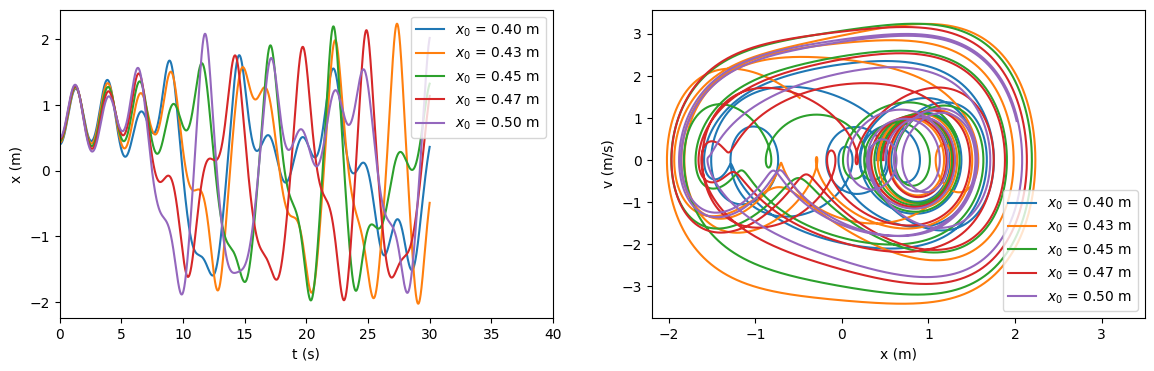

In [88]:
n_par = 5 # Number of different values for x0

# x0 and v0 definen
x0_array = np.linspace(0.4,0.5,n_par)
v0_array = np.zeros([n_par])

# Plotten van x-t en x-p diagrammen
plt.figure(figsize=[14,4])
for j in range(n_par):                          #Looping over all the initial conditions
    x = np.zeros(N)
    v = np.zeros(N)
    x[0],v[0] = x0_array[j],v0_array[j]

    for i in range(1,N):                        #Solve for x and v using Verlet algorithm
        x[i],v[i] = Verlet(x[i-1],v[i-1],t[i-1])

    plt.subplot(121) # Plot x,t diagram left
    plt.plot(t,x,label="$x_0$ = %.2f m" %(x0_array[j]))
    plt.subplot(122) # Plot x,p diagram right
    plt.plot(x,v,label="$x_0$ = %.2f m" %(x0_array[j]))

# Setting up the right notation
plt.subplot(122)
plt.xlabel("x (m)")
plt.ylabel("v (m/s)")
plt.legend()
plt.xlim(-2.2,3.5)
plt.subplot(121)
plt.xlabel("t (s)")
plt.ylabel("x (m)")
plt.xlim(0,40)
plt.legend()

In [ ]:
n_par = 5 # number of different values for x0

# x0 and v0 definen
v0_array = np.linspace(0,0.1,n_par)
x0_array = np.zeros([n_par])+0.5

# Plotten van x-t en x-p diagrammen
x[0],v[0] = x0,v0
plt.figure(figsize=[14,4])
for j in range(n_par): # Loop over all the initial conditions
    x = np.zeros(N)
    v = np.zeros(N)
    x[0],v[0] = x0_array[j],v0_array[j]
    for i in range(1,N):
        x[i],v[i] = Verlet(x[i-1],v[i-1],t[i-1]) # Solve for x and v using Verlet algorithm
    plt.subplot(121)
    plt.plot(t,x,label="$v_0$ = %.3f m/s" %(v0_array[j]))
    plt.subplot(122)
    plt.plot(x,v,label="$v_0$ = %.3f m/s" %(v0_array[j]))

# Setting up the right notation
plt.subplot(122)
plt.xlabel("x (m)")
plt.ylabel("v (m/s)")
plt.legend()
plt.xlim(-2.2,3.5)
plt.subplot(121) # Plot x,p diagram right
plt.xlabel("t (s)")
plt.ylabel("x (m)")
plt.xlim(0,40)
plt.legend()

## c)  Plotting the Strange Attractor

In [ ]:
N = 100000000
N_T = 1000
T = 2*np.pi/w
t = np.arange(0,(N)*T/N_T,T/N_T)
h = t[1]-t[0]
n = np.arange(0,N,N_T)

In [ ]:
n_par = 5 # number of different values for x0

# x0 and v0 definen
x0 = 0.5
v0 = 0

# Calculating 
x = np.zeros(N)
v = np.zeros(N)
x[0],v[0] = x0,v0
for i in range(1,N):
    x[i],v[i] = Verlet(x[i-1],v[i-1],t[i-1]) # Solve for x and v using Verlet algorithm

In [ ]:
plt.subplot(131)
plt.plot(x[n],v[n],"c.",ms=0.01)
plt.xlabel("x (m)")
plt.ylabel("v (m/s)")


plt.subplot(132)
plt.xlim(-0.5,0.5)
plt.ylim(-0.5,0.5)
plt.plot(x[n],v[n],"c.",ms=0.1)
plt.xlabel("x (m)")
plt.ylabel("v (m/s)")


plt.subplot(133)
plt.xlim(-0.35,-0.05)
plt.ylim(-0.35,-0.05)
plt.plot(x[n],v[n],"c.",ms=1)
plt.xlabel("x (m)")
plt.ylabel("v (m/s)")


plt.show()

plt.plot(t[0:int(N/10000)],x[0:int(N/10000)])

## d)

## e)

In [ ]:
#Normalizing to [0,1]
def norm(p):
    shifted = p-np.min(p)               #Shifting minimal p value to 0
    width = np.max(p)-np.min(p)
    scale = 1/width                     #Scaling factor to get width=1

    return shifted*scale

norm_x = norm(x[n])
norm_v = norm(v[n])


#Calculating dimension
def dimcount(l):
    #First multiplying by l and flooring to get an integer value belonging to a square
    x_cnt = np.floor(norm_x*l)
    y_cnt = np.floor(norm_v*l)

    #Boundaries check
    x_cnt[x_cnt==1] = l-1
    y_cnt[y_cnt==1] = l-1

    vec = np.vstack((x_cnt,y_cnt)).T        #Storing everything as a vector for the following
    uniques = np.unique(vec, axis=0)        #Removing duplicates to get the amount of boxes that have at least one point
    return len(uniques)


#Storing the l values
exp_max = 10
l = np.zeros([exp_max])
for i in range(0,exp_max):
    l[i] = 2**(i+1)


#Calculating N
amount = np.zeros([len(l)])
for i in range(len(l)):
    amount[i] = dimcount(l[i])


#Plotting (sanity check)
plt.plot(norm_x,norm_v,"c.",ms=1)

plt.gca().xaxis.set_minor_locator(MultipleLocator(1/16))
plt.gca().yaxis.set_minor_locator(MultipleLocator(1/16))

plt.grid(which='minor', linestyle=':', alpha=0.5)

plt.xlim(0,1)
plt.ylim(0,1)
plt.xlabel("x (m)")
plt.ylabel("v (m/s)")
plt.show()

In [ ]:
#Curve Fitting
def N_b(b,D):
    return b**(-D)

val, cov = curve_fit(N_b,1/l, amount)
x = np.linspace(min(1/l),max(1/l),1000)
y = N_b(x, *val)

D = val[0]
u_D = np.sqrt(cov[0,0])
print('The dimension of the attractor is: D =  %f +/- %f. This is not an integer, and therefore it is a strange attractor'%(D, u_D))

#Plotting
plt.plot(-np.log(1/l),np.log(amount),".")
plt.plot(-np.log(x),np.log(y))
plt.grid()
plt.show()